# Prediction Error Reduction Attribution

This notebook performs the four-stage ablation analysis for **HV, EC and Q3 using XGBoost throughout**. Stage 0–2 use the same fixed XGBoost configuration; Stage 3 retains the Stage 2 feature matrix and tunes XGBoost using training-set cross-validation only.

The three feature inputs may use different Excel files, sheets, row orders and feature columns. Records are aligned using normalized IDs before one fixed 80/20 split is created.

In [15]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
from IPython.display import display, Image

# All editable settings are located in the next code cell.

Working directory: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/ML2/消融实验/Prediction_Error_Attribution


## 1. User configuration trunk

All user-editable paths, column mappings, model settings and run switches are collected in the single code cell below. The keys `S0`, `S1` and `S2` refer to scientific roles, not to the numbers in file names:

- `S0`: composition-only baseline;
- `S1`: physicochemical feature engineering;
- `S2`: CTD-derived CPSP features.

The cell writes the selected settings to `runtime_config.json`; the original configuration is retained as a template. No settings need to be changed in later cells.

In [16]:
# ==============================================================================
# USER CONFIGURATION TRUNK — edit settings only inside this cell
# ==============================================================================
# Scientific order:
#   S0 = composition-only baseline
#   S1 = S0 + conventional physicochemical descriptors
#   S2 = S1 + CTD-derived CPSP descriptors
#   S3 = S2 features + training-only CV optimization of XGBoost
#
# Important:
#   1. File names Feature1/2/3 do not automatically determine the Stage.
#   2. The three tables may have different sheet names and target-column names.
#   3. Keep RUN_FORMAL_EXPERIMENT=False until the audit passes.
#   4. Quick results are diagnostic only and must not be reported in the paper.
# ==============================================================================

# ---- A. Working files ---------------------------------------------------------
WORK_DIR = Path('/Users/zixuanzhao/Desktop/Corpus–Topic–Document/ML2/消融实验/Prediction_Error_Attribution')
BASE_CONFIG_PATH = WORK_DIR / 'attribution_config.json'
RUNTIME_CONFIG_PATH = WORK_DIR / 'runtime_config.json'
SCRIPT_PATH = WORK_DIR / 'prediction_error_attribution.py'

# ---- B. Manually assign each input table to its scientific Stage -------------
USER_STAGE_FILES = {
    'S0': '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature2.xlsx',
    'S1': '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature1.xlsx',
    'S2': '/Users/zixuanzhao/Desktop/Corpus–Topic–Document/FE/Feature/Feature3.xlsx',
}

# ---- C. Sheet names in each input table --------------------------------------
USER_STAGE_SHEETS = {
    'S0': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
    'S1': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
    'S2': {'HV': 'HV', 'EC': 'EC', 'Q3': 'Q3-Eu'},
}

# ---- D. Target-column names in each input table ------------------------------
USER_STAGE_TARGET_COLUMNS = {
    'S0': {'HV': 'Hardness/HV', 'EC': 'EC/%IACS', 'Q3': 'Q3-Euclidean'},
    'S1': {'HV': 'HV',          'EC': 'EC',       'Q3': 'Q3-Eu'},
    'S2': {'HV': 'HV',          'EC': 'EC',       'Q3': 'Q3-Eu'},
}

# ---- E. Experiment and execution switches ------------------------------------
MODEL_BY_PROPERTY = {'HV': 'XGB', 'EC': 'XGB', 'Q3': 'XGB'}
RANDOM_SEED = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
STAGE3_SEARCH_ITERATIONS = 30
RUN_QUICK_TEST = False          # True: run a 3-draw diagnostic search
RUN_FORMAL_EXPERIMENT = False   # True: run the formal 30-draw experiment
USE_QUICK_RESULTS = True        # False: read formal results from results/
# ==============================================================================

# Build a runtime configuration from the settings above.
assert WORK_DIR.exists(), f'Missing directory: {WORK_DIR}'
assert BASE_CONFIG_PATH.exists(), f'Missing config: {BASE_CONFIG_PATH}'
assert SCRIPT_PATH.exists(), f'Missing analysis script: {SCRIPT_PATH}'
with BASE_CONFIG_PATH.open('r', encoding='utf-8') as f:
    config = json.load(f)

for stage in ['S0', 'S1', 'S2']:
    config['stages'][stage]['file'] = USER_STAGE_FILES[stage]
    config['stages'][stage]['sheets'] = USER_STAGE_SHEETS[stage]
    config['stages'][stage]['target_columns'] = USER_STAGE_TARGET_COLUMNS[stage]
for prop in ['HV', 'EC', 'Q3']:
    config['targets'][prop]['model'] = MODEL_BY_PROPERTY[prop]
config['random_seed'] = RANDOM_SEED
config['test_size'] = TEST_SIZE
config['cv_folds'] = CV_FOLDS
config['stage3_search_iterations'] = STAGE3_SEARCH_ITERATIONS

with RUNTIME_CONFIG_PATH.open('w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
CONFIG_PATH = RUNTIME_CONFIG_PATH

model_map = {prop: item['model'] for prop, item in config['targets'].items()}
assert model_map == MODEL_BY_PROPERTY, model_map

configuration_table = pd.DataFrame([
    {
        'Stage': stage,
        'Meaning': stage_cfg['label'],
        'Input file': stage_cfg['file'],
        'HV sheet': stage_cfg['sheets']['HV'],
        'EC sheet': stage_cfg['sheets']['EC'],
        'Q3 sheet': stage_cfg['sheets']['Q3'],
        'Target columns (HV | EC | Q3)': ' | '.join(stage_cfg['target_columns'][p] for p in ['HV', 'EC', 'Q3']),
        'Configured feature rule': (
            'All non-ID/target columns'
            if stage_cfg['features']['HV'] == '__ALL_EXCEPT_ID_AND_TARGET__'
            else 'Explicit role-specific feature lists'
        ),
    }
    for stage, stage_cfg in config['stages'].items()
])
print('Models:', model_map)
print('Runtime config:', CONFIG_PATH)
print('Cumulative features:', config.get('cumulative_features', True))
display(configuration_table)

Models: {'HV': 'XGB', 'EC': 'XGB', 'Q3': 'XGB'}
Runtime config: /Users/zixuanzhao/Desktop/Corpus–Topic–Document/ML2/消融实验/Prediction_Error_Attribution/runtime_config.json
Cumulative features: True


,Stage,Meaning,Input file,HV sheet,EC sheet,Q3 sheet,Target columns (HV | EC | Q3),Configured feature rule
0,S0,Composition-only,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV,EC,Q3-Eu,Hardness/HV | EC/%IACS | Q3-Euclidean,Explicit role-specific feature lists
1,S1,Physicochemical feature engineering,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV,EC,Q3-Eu,HV | EC | Q3-Eu,Explicit role-specific feature lists
2,S2,CTD-derived CPSP knowledge,/Users/zixuanzhao/Desktop/Corpus–Topic–Documen...,HV,EC,Q3-Eu,HV | EC | Q3-Eu,All non-ID/target columns


## 2. Input and split audit

This step checks source files, sheets, required columns, numeric features, duplicate IDs, common IDs and target consistency. It writes `input_audit.csv` and `split_map.csv` but does not train a model.

In [17]:
audit = subprocess.run(
    [sys.executable, str(SCRIPT_PATH), '--config', str(CONFIG_PATH), '--audit-only'],
    cwd=WORK_DIR, text=True, capture_output=True
)
print(audit.stdout)
if audit.returncode != 0:
    print(audit.stderr)
    raise RuntimeError('Input audit failed. Correct the configuration before training.')

Input audit passed. Common IDs and feature counts:
Property Stage  Common_Valid_IDs  Feature_Count
      HV    S0              1136              7
      HV    S1              1136             17
      HV    S2              1136             24
      EC    S0              1136              7
      EC    S1              1136             14
      EC    S2              1136             22
      Q3    S0              1136              7
      Q3    S1              1136             18
      Q3    S2              1136             23



In [18]:
audit_table = pd.read_csv(Path(config['output_directory']) / 'input_audit.csv')
split_table = pd.read_csv(Path(config['output_directory']) / 'split_map.csv')
display(audit_table[['Property', 'Stage', 'Stage_Label', 'Common_Valid_IDs', 'Feature_Count']])

test_sets = {
    prop: set(split_table.query("Property == @prop and Split == 'Test'")['ID'].astype(str))
    for prop in ['HV', 'EC', 'Q3']
}
assert test_sets['HV'] == test_sets['EC'] == test_sets['Q3'], 'Test IDs differ across properties'
print('Shared test IDs:', len(test_sets['HV']))
print('The HV, EC and Q3 test ID sets are identical.')

,Property,Stage,Stage_Label,Common_Valid_IDs,Feature_Count
0,HV,S0,Composition-only,1136,7
1,HV,S1,Physicochemical feature engineering,1136,17
2,HV,S2,CTD-derived CPSP knowledge,1136,24
3,EC,S0,Composition-only,1136,7
4,EC,S1,Physicochemical feature engineering,1136,14
5,EC,S2,CTD-derived CPSP knowledge,1136,22
6,Q3,S0,Composition-only,1136,7
7,Q3,S1,Physicochemical feature engineering,1136,18
8,Q3,S2,CTD-derived CPSP knowledge,1136,23


Shared test IDs: 228
The HV, EC and Q3 test ID sets are identical.


## 3. Quick end-to-end test

This diagnostic run uses only three Stage 3 parameter draws and saves outputs to `results_quick`. Do not use these values as the final paper results.

In [19]:
if RUN_QUICK_TEST:
    quick = subprocess.run(
        [sys.executable, str(SCRIPT_PATH), '--config', str(CONFIG_PATH), '--quick'],
        cwd=WORK_DIR, text=True
    )
    if quick.returncode != 0:
        raise RuntimeError('Quick run failed.')
else:
    print('Quick run skipped. Set RUN_QUICK_TEST = True to execute it.')

Quick run skipped. Set RUN_QUICK_TEST = True to execute it.


## 4. Formal XGBoost attribution experiment

Set `RUN_FORMAL_EXPERIMENT = True` and run this cell. The default Stage 3 search evaluates 30 XGBoost parameter combinations with 5-fold CV on the training set. Final outputs are written to `results`.

In [20]:
if RUN_FORMAL_EXPERIMENT:
    formal = subprocess.run(
        [sys.executable, str(SCRIPT_PATH), '--config', str(CONFIG_PATH)],
        cwd=WORK_DIR, text=True
    )
    if formal.returncode != 0:
        raise RuntimeError('Formal experiment failed.')
else:
    print('Formal experiment not started. Set RUN_FORMAL_EXPERIMENT = True when ready.')

Formal experiment not started. Set RUN_FORMAL_EXPERIMENT = True when ready.


## 5. Read and verify results

Choose `USE_QUICK_RESULTS = False` for the formal paper results. Negative sequential contributions are retained and flagged rather than truncated to zero.

In [21]:
RESULT_DIR = Path(config['output_directory'] + ('_quick' if USE_QUICK_RESULTS else ''))

required_outputs = [
    'run_summary.csv', 'predictions_long.csv', 'attribution_summary.csv',
    'best_parameters.csv', 'split_map.csv', 'input_audit.csv'
]
missing_outputs = [name for name in required_outputs if not (RESULT_DIR / name).exists()]
if missing_outputs:
    raise FileNotFoundError(f'Run the selected experiment first. Missing: {missing_outputs}')

run_summary = pd.read_csv(RESULT_DIR / 'run_summary.csv')
attribution = pd.read_csv(RESULT_DIR / 'attribution_summary.csv')
best_parameters = pd.read_csv(RESULT_DIR / 'best_parameters.csv')

assert set(run_summary['Model']) == {'XGB'}, run_summary['Model'].unique()
assert attribution['Telescoping_Check'].abs().max() < 1e-10
display(run_summary[[
    'Property', 'Stage', 'Model', 'Optimized', 'Feature_Count',
    'Train_R2', 'Test_R2', 'Test_RMSE', 'Test_Target_SD_ddof0', 'Test_NRMSE'
]])
display(attribution)

,Property,Stage,Model,Optimized,Feature_Count,Train_R2,Test_R2,Test_RMSE,Test_Target_SD_ddof0,Test_NRMSE
0,HV,S0,XGB,False,7,0.519083,0.538739,52.919378,77.918649,0.679162
1,HV,S1,XGB,False,17,0.519821,0.540731,52.805002,77.918649,0.677694
2,HV,S2,XGB,False,24,0.909730,0.821174,32.950093,77.918649,0.422878
3,HV,S3,XGB,True,24,0.867100,0.824025,32.686395,77.918649,0.419494
4,EC,S0,XGB,False,7,0.406875,0.396658,9.407800,12.111732,0.776751
5,EC,S1,XGB,False,14,0.407078,0.394376,9.425578,12.111732,0.778219
6,EC,S2,XGB,False,22,0.843123,0.679765,6.853943,12.111732,0.565893
7,EC,S3,XGB,True,22,0.780401,0.677797,6.874971,12.111732,0.567629
8,Q3,S0,XGB,False,7,0.597683,0.554147,0.082041,0.122867,0.667722
9,Q3,S1,XGB,False,18,0.607083,0.575938,0.080011,0.122867,0.651200


,Property,E0,E1,E2,E3,Physics contribution,CTD contribution,Model contribution,Residual error,Physics_%_of_E0,CTD_%_of_E0,Model_%_of_E0,Residual_%_of_E0,Telescoping_Check,Negative_Component_Flag
0,HV,0.679162,0.677694,0.422878,0.419494,0.001468,0.254816,0.003384,0.419494,0.216131,37.519167,0.498300,61.766402,0.0,False
1,EC,0.776751,0.778219,0.565893,0.567629,-0.001468,0.212326,-0.001736,0.567629,-0.188963,27.335127,-0.223515,73.077351,0.0,True
2,Q3,0.667722,0.651200,0.491806,0.488384,0.016522,0.159394,0.003422,0.488384,2.474371,23.871346,0.512522,73.141761,0.0,False


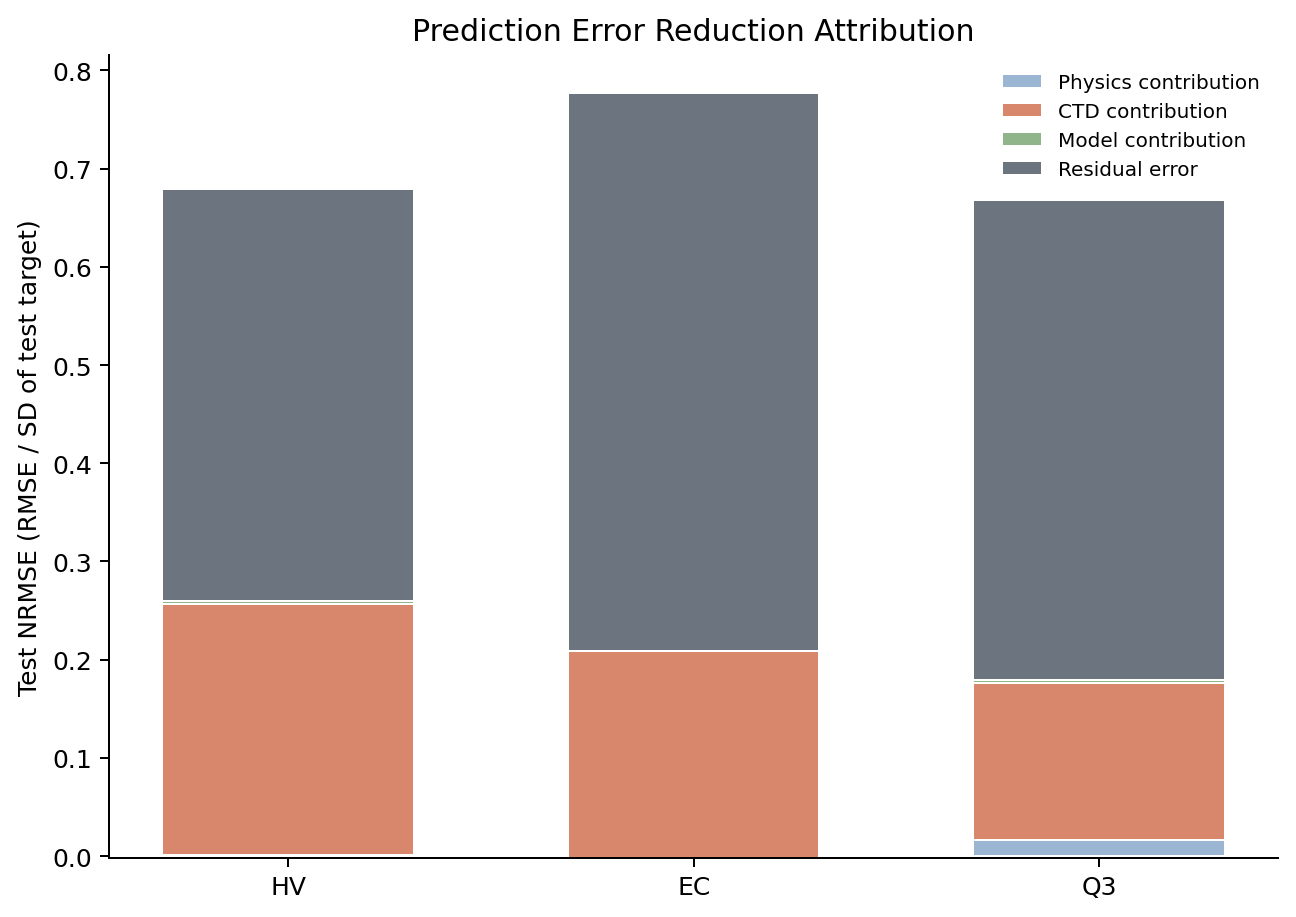

In [8]:
figure_path = RESULT_DIR / 'prediction_error_attribution.png'
display(Image(filename=str(figure_path)))

## Interpretation guardrails

- Use **Test NRMSE**, not skew R², for prediction-error attribution.
- Stage 0–2 keep the XGBoost algorithm and fixed hyperparameters unchanged.
- Stage 3 uses the Stage 2 samples and features unchanged; only XGBoost hyperparameters change.
- Hyperparameter selection is conducted inside the training set.
- A negative contribution means that the corresponding step did not reduce test error under this split. It must be reported, not forced to zero.
- Residual error is not numerically equated with literature uncertainty; it may reflect data variability, incomplete coverage, missing descriptors, measurement uncertainty and model limitations.